In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# dataframe will be used to plot heatmap
df_hourly_stats = pd.read_parquet('../data/processed/hourly_stats.parquete')
df_hourly_stats.columns

In [ ]:
cc_trips = pd.read_parquet('../data/processed/cleaned_credit_card_trips.parquet')
cc_trips.head()

### Target Creation & Class Imbalance

In [ ]:
# Determining generous tip
cc_trips['is_generous_tip'] = (cc_trips['tip_percentage'] > 20).astype(int)
cc_trips['is_generous_tip']

# Generous tip distribution
generous_dist = cc_trips['is_generous_tip'].value_counts(normalize = True)*100
generous_dist.head()

### Feature Engineering, Splitting, and Scaling

In [ ]:
# Duration in minutes
cc_trips['trip_duration'] = (cc_trips['tpep_dropoff_datetime'] - cc_trips['tpep_pickup_datetime']).dt.total_seconds() / 60.0

# Defining features and target
features = ['trip_distance', 'fare_amount', 'trip_duration', 'pickup_hour']
X = cc_trips[features]
y = cc_trips['is_generous_tip']

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

### Model Training, Evaluation, and Business Insight

In [ ]:
# model training
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Prediction
y_pred = model.predict(X_test_scaled)

# evaluation
print(f'Accuracy Score {accuracy_score(y_test, y_pred)}')
print(f'Classification Report {classification_report(y_test, y_pred)}')

### Advanced Modeling & Interpretability

### Extracting Logistic Regression Insights

In [ ]:
# Extracting coefficients (model.coef_[0])
coefficients = model.coef_[0]

# Matching coefficients to a datframe
df_coefficients = pd.DataFrame({
    'Features': features,
    'Coefficients': coefficients
})
df_coefficients_sorted = df_coefficients.sort_values(by='Coefficients', ascending=False)

strongest_positive = df_coefficients_sorted.loc[df_coefficients_sorted['Coefficients'].idxmax(), ['Features', 'Coefficients']]
strongest_positive
print(f'{strongest_positive['Features']} has the strongest positive coefficient {strongest_positive['Coefficients']} which makes sense')

### Upgrading to an Ensemble Model (Random Forest)

In [ ]:
# Instantiate and train Random Forest
model_rf = RandomForestClassifier(n_estimators=100,max_depth=10, random_state=42,n_jobs=-1)
model_rf.fit(X_train_scaled, y_train)

# predicting
y_pred_rf = model_rf.predict(X_test_scaled)


In [ ]:
# Classification report
print(f'Classification report\n: {classification_report(y_test, y_pred_rf)}')

### Visualization

In [ ]:
# Extracting feature importance from rf model
importance = model_rf.feature_importances_

# Creating a df and sorting in ascending
df_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by = 'Importance', ascending = True)

sns.set_theme(style = 'whitegrid')
plt.figure(figsize = (10,6))

sns.barplot(
    x = 'Feature',
    y = 'Importance',
    data = df_importance,
    legend= False,
    hue= 'Feature',
    palette = 'viridis'
)

plt.title('Key Drivers of Generous Tipping Behavior using Random Forest')
plt.xlabel('Trip Feature')
plt.ylabel('Feature Importance Score')
plt.tight_layout()

plt.savefig('../images/generous_tipping_drivers.png', dpi = 300, bbox_inches = 'tight')

plt.show()

### Weekly Demand & Fare Heatmap

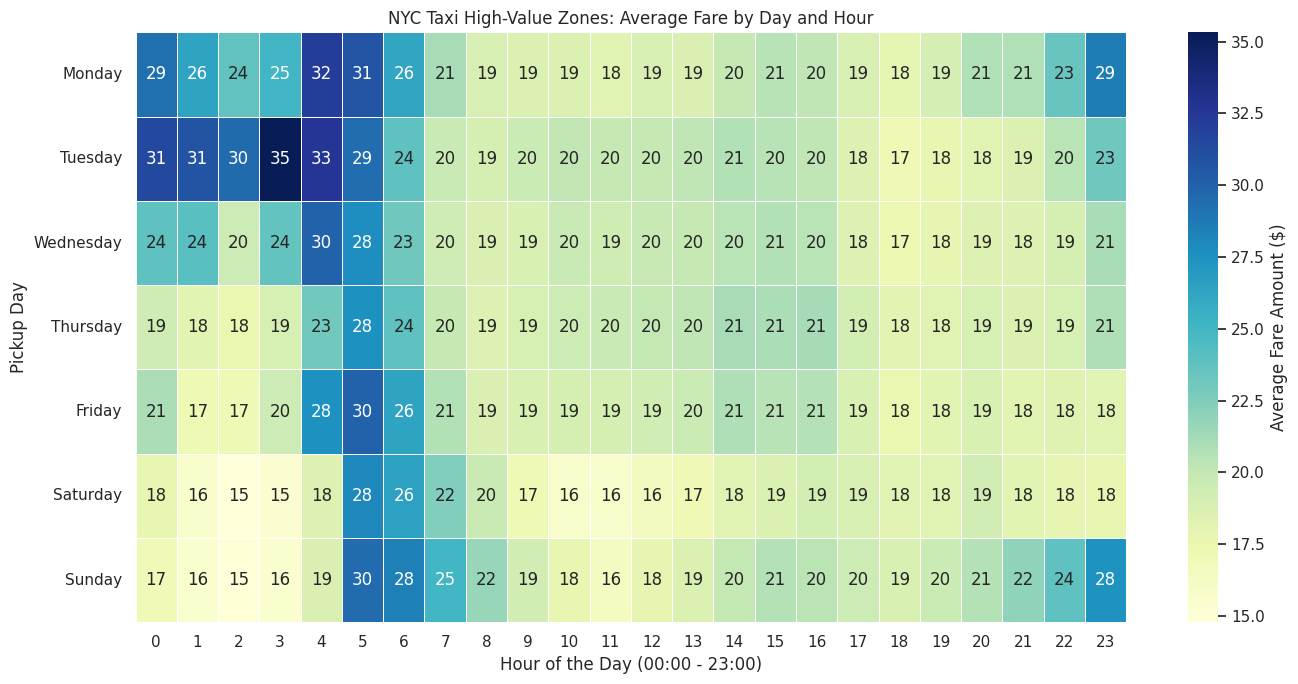

In [30]:
# reset index
df_hourly_stats_reset = df_hourly_stats.reset_index()

# Pivot using the reset DataFrame
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = df_hourly_stats_reset.pivot(index='pickup_day', columns='pickup_hour', values='avg_fare')

# Reindex so days display in correct calendar order (Mon-Sun)
heatmap_data = heatmap_data.reindex(day_order)

# Setting up the plotting canvas
plt.figure(figsize=(14, 7))

# plotting
sns.heatmap(
    heatmap_data, 
    cmap='YlGnBu', 
    annot=True, # shows fare amount in every square
    linewidths=.5,
    cbar_kws={'label': 'Average Fare Amount ($)'}
)


plt.title('NYC Taxi High-Value Zones: Average Fare by Day and Hour')
plt.xlabel('Hour of the Day (00:00 - 23:00)')
plt.ylabel('Pickup Day')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig('../images/weekly_demand.png', dpi = 300, bbox_inches = 'tight')

plt.show()